# Student Performance Prediction: Exploratory Data Analysis & Multiple Linear Regression from Scratch

In this notebook, we analyze the **Student Performance Dataset** (10,000 observations) to understand what factors influence academic performance, and implement **Multiple Linear Regression from Scratch** using pure NumPy and vectorized mathematics.

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [35]:
df = pd.read_csv('/home/yashwanth-aravind/ml-gym/01-linear-regression/data/Student-Performance-data/Student_Performance.csv')

In [36]:
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [37]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  str    
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), str(1)
memory usage: 468.9 KB


In [38]:
df.describe()

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.992900,69.445700,6.530600,4.583300,55.224800
std,2.589309,17.343152,1.695863,2.867348,19.212558
min,1.000000,40.000000,4.000000,0.000000,10.000000
25%,3.000000,54.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,7.000000,5.000000,55.000000
75%,7.000000,85.000000,8.000000,7.000000,71.000000
max,9.000000,99.000000,9.000000,9.000000,100.000000


In [39]:
df.isnull().sum()

Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64

In [40]:
# Check for duplicate rows
duplicates = df.duplicated().sum()
print(f"Total duplicate rows: {duplicates}")

# Remove duplicate rows to ensure data integrity
if duplicates > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print(f"Dataset shape after dropping duplicates: {df.shape}")

Total duplicate rows: 127
Dataset shape after dropping duplicates: (9873, 6)


In [41]:
df['Extracurricular Activities'].value_counts()

Extracurricular Activities
No     4986
Yes    4887
Name: count, dtype: int64

In [42]:
df['Extracurricular Activities']=df['Extracurricular Activities'].map({'Yes': 1, 'No': 0})

<Axes: >

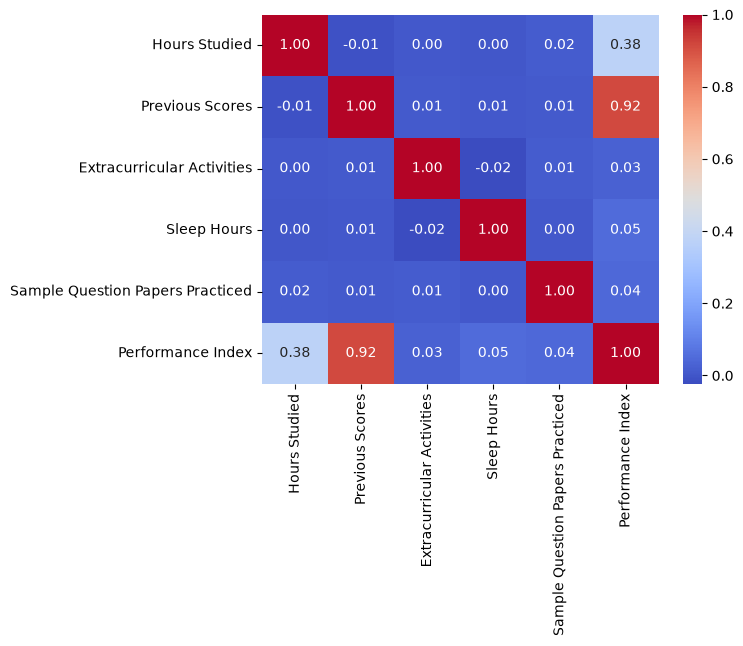

In [ ]:
sns.heatmap(df.corr(),annot=True,fmt=".2f", cmap='coolwarm')

/tmp/ipykernel_364251/3033481894.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col].map({1: 'Yes', 0: 'No'}), ax=ax, palette=['#4C72B0', '#55A868'])


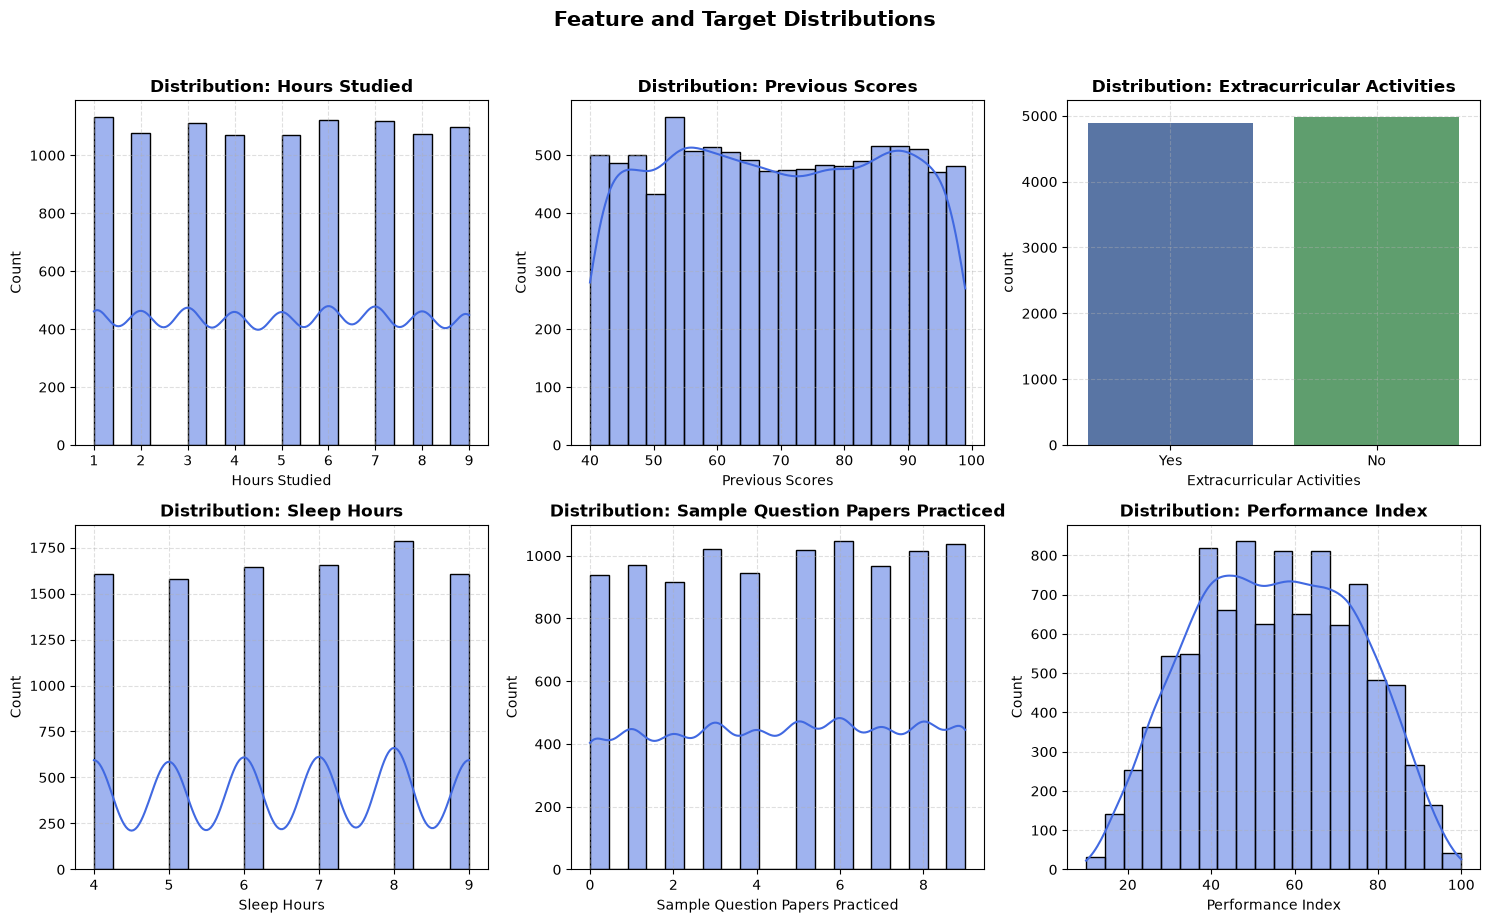

In [44]:
# 1. Univariate Distributions across all features and target
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
features = df.columns.tolist()

for i, col in enumerate(features):
    ax = axes[i // 3, i % 3]
    if col == 'Extracurricular Activities':
        sns.countplot(x=df[col].map({1: 'Yes', 0: 'No'}), ax=ax, palette=['#4C72B0', '#55A868'])
        ax.set_title(f'Distribution: {col}', fontweight='bold')
    else:
        sns.histplot(df[col], kde=True, ax=ax, color='royalblue', bins=20)
        ax.set_title(f'Distribution: {col}', fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.4)

plt.suptitle("Feature and Target Distributions", fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

/tmp/ipykernel_364251/1261825299.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[col].map({1: 'Yes', 0: 'No'}), y=df['Performance Index'], ax=ax, palette=['#4C72B0', '#55A868'])


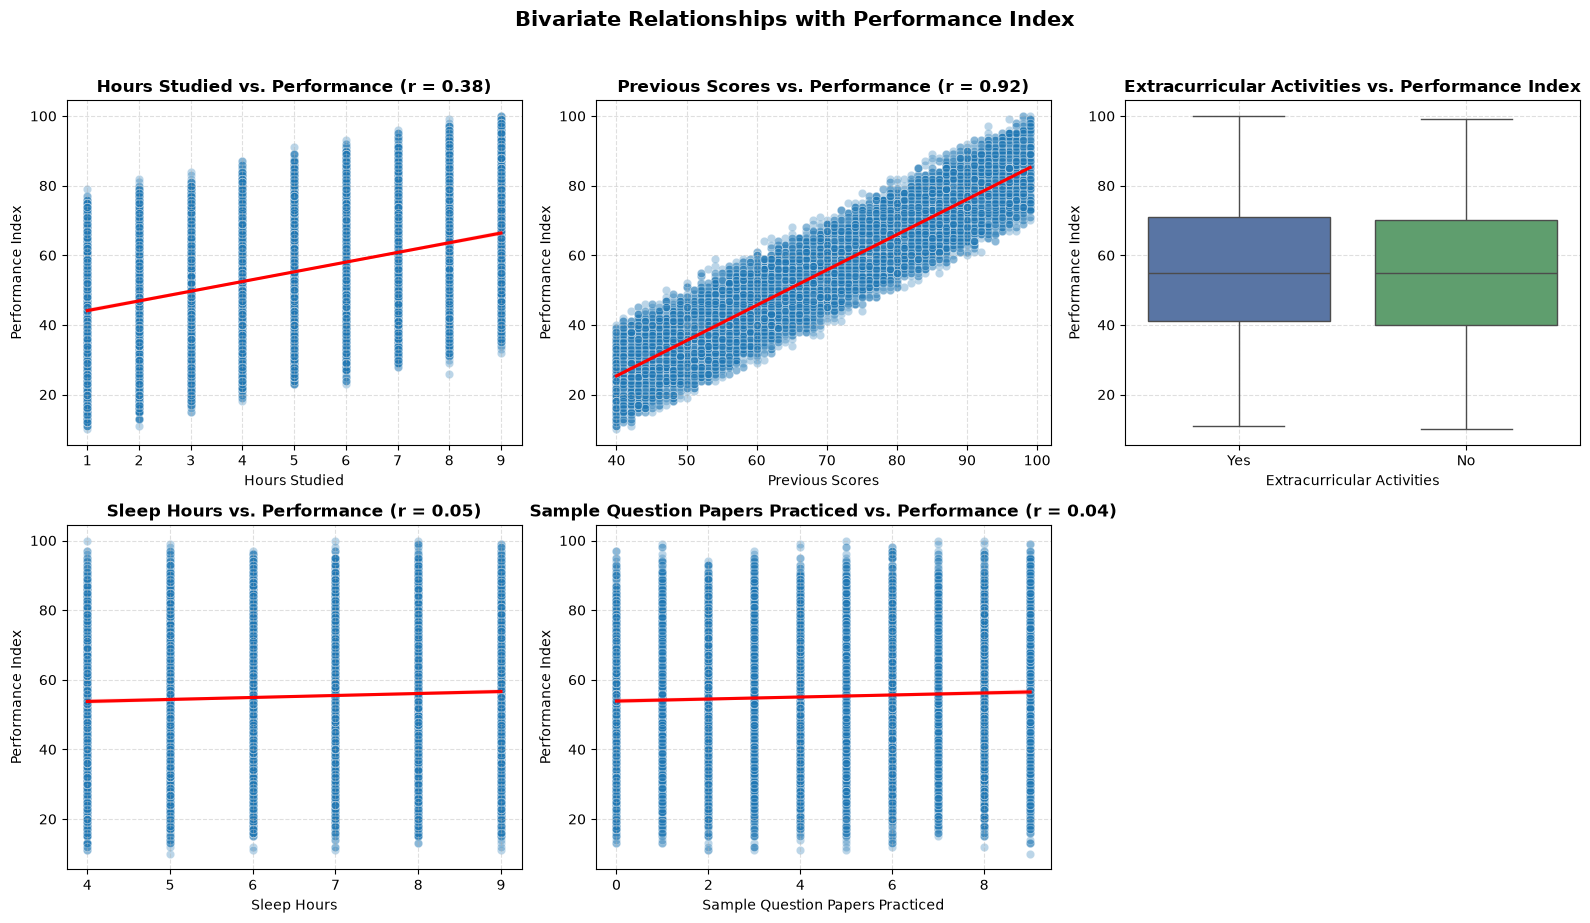

In [45]:
# 2. Bivariate Analysis: Features vs. Target (Performance Index)
input_cols = [c for c in df.columns if c != 'Performance Index']
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for i, col in enumerate(input_cols):
    ax = axes[i // 3, i % 3]
    if col == 'Extracurricular Activities':
        sns.boxplot(x=df[col].map({1: 'Yes', 0: 'No'}), y=df['Performance Index'], ax=ax, palette=['#4C72B0', '#55A868'])
        ax.set_title(f'{col} vs. Performance Index', fontweight='bold')
    else:
        sns.scatterplot(x=df[col], y=df['Performance Index'], ax=ax, alpha=0.3, color='tab:blue')
        # Add regression trendline
        sns.regplot(x=df[col], y=df['Performance Index'], ax=ax, scatter=False, color='red')
        r_val = df[col].corr(df['Performance Index'])
        ax.set_title(f'{col} vs. Performance (r = {r_val:.2f})', fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.4)

# Remove empty subplot in 2x3 grid
fig.delaxes(axes[1, 2])

plt.suptitle("Bivariate Relationships with Performance Index", fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

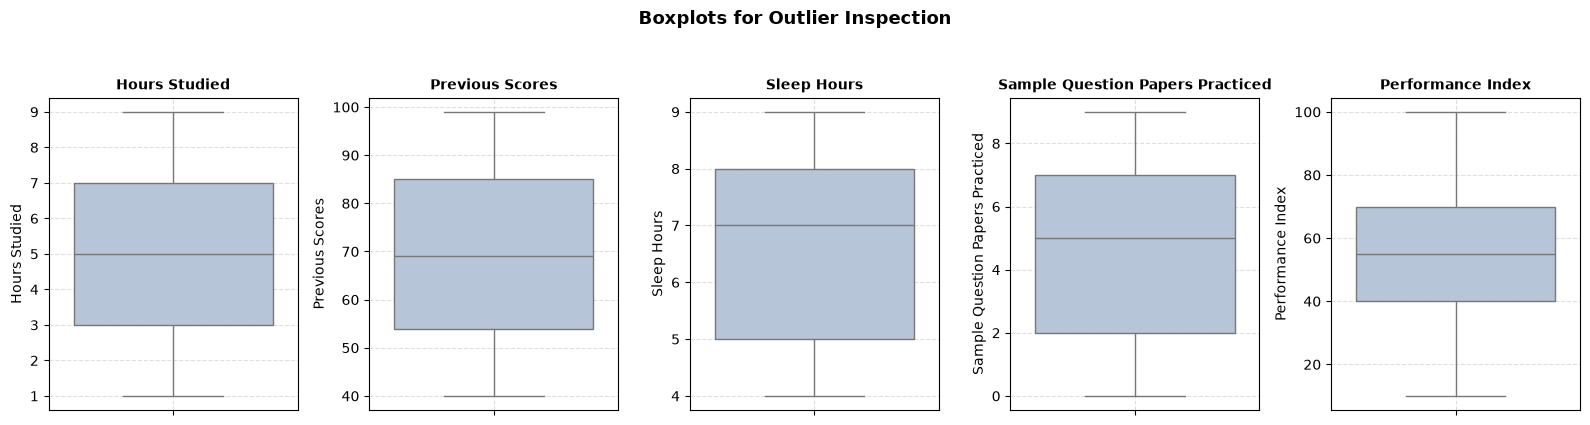

In [46]:
# 3. Outlier Detection across Numerical Features
num_cols = ['Hours Studied', 'Previous Scores', 'Sleep Hours', 'Sample Question Papers Practiced', 'Performance Index']
fig, axes = plt.subplots(1, 5, figsize=(16, 4))

for i, col in enumerate(num_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='lightsteelblue')
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].grid(True, linestyle='--', alpha=0.4)

plt.suptitle("Boxplots for Outlier Inspection", fontsize=13, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

---

## Key EDA Findings & Strategic Takeaways for Modeling

1. **Dominant Feature:**
   - **`Previous Scores`** has an extraordinary correlation with the target ($r = +0.92$). The scatter plot shows an almost perfect linear band. A student with high past scores is almost guaranteed a high performance index.
2. **Secondary Feature:**
   - **`Hours Studied`** exhibits a strong positive relationship ($r = +0.37$). The scatter plot reveals distinct stratified bands stepping upward as study hours increase.
3. **Minor Features:**
   - `Sleep Hours` ($r = 0.05$), `Sample Question Papers Practiced` ($r = 0.04$), and `Extracurricular Activities` ($r = 0.02$) have very low linear correlation on their own, but contribute small incremental signals.
4. **Zero Multicollinearity:**
   - All pairwise correlations between input features are nearly **$0.00$** ($|r| < 0.02$). This means features are completely orthogonal—ideal for linear regression, ensuring stable regression coefficients with zero variance inflation!
5. **No Significant Outliers:**
   - All features are cleanly bounded within realistic expected ranges (`Hours Studied`: 1–9, `Previous Scores`: 40–99, `Sleep`: 4–9, `Papers`: 0–9).
6. **Modeling Strategy:**
   - Because features are measured on different scales (e.g., scores $40\text{--}99$ vs. hours $1\text{--}9$), we must apply **StandardScaler feature normalization** before running Batch Gradient Descent.

---

## Part 2: Data Preprocessing & Train-Test Split

To rigorously evaluate our model, we:
1. Separate features $\mathbf{X}$ and target $\mathbf{y}$.
2. Perform an **80/20 Train-Test split**.
3. Apply **Z-Score Normalization (StandardScaler)**:
   $$\mathbf{X}_{\text{scaled}} = \frac{\mathbf{X} - \boldsymbol{\mu}}{\boldsymbol{\sigma}}$$
   *Note:* $\boldsymbol{\mu}$ and $\boldsymbol{\sigma}$ are computed strictly on the training set and applied to the test set to avoid data leakage.

In [47]:
# 1. Feature matrix X and target vector y
feature_cols = ['Hours Studied', 'Previous Scores', 'Extracurricular Activities', 'Sleep Hours', 'Sample Question Papers Practiced']
X = df[feature_cols].values
y = df['Performance Index'].values.reshape(-1, 1)

# 2. Train-Test Split (80% Train, 20% Test)
np.random.seed(42)
N = len(X)
shuffled_indices = np.random.permutation(N)
train_size = int(0.8 * N)

train_idx = shuffled_indices[:train_size]
test_idx = shuffled_indices[train_size:]

X_train, y_train = X[train_idx], y[train_idx]
X_test, y_test = X[test_idx], y[test_idx]

# 3. Feature Scaling (StandardScaler from scratch)
mu = np.mean(X_train, axis=0)
sigma = np.std(X_train, axis=0)

X_train_scaled = (X_train - mu) / sigma
X_test_scaled = (X_test - mu) / sigma

print(f"Training set: X_train shape = {X_train_scaled.shape}, y_train shape = {y_train.shape}")
print(f"Testing set:  X_test shape  = {X_test_scaled.shape}, y_test shape  = {y_test.shape}")

Training set: X_train shape = (7898, 5), y_train shape = (7898, 1)
Testing set:  X_test shape  = (1975, 5), y_test shape  = (1975, 1)


---

## Part 3: Multiple Linear Regression from Scratch (Batch Gradient Descent)

### Mathematical Formulation
For $d = 5$ features and $N$ training examples:
$$\hat{\mathbf{y}} = \mathbf{X}_{\text{scaled}} \mathbf{w} + b\mathbf{1}$$

$$\text{MSE Loss: } J(\mathbf{w}, b) = \frac{1}{N} \sum_{i=1}^N (\hat{y}^{(i)} - y^{(i)})^2$$

### Vectorized Gradient Formulas:
$$\mathbf{e} = \hat{\mathbf{y}} - \mathbf{y}$$
$$\nabla_{\mathbf{w}} J = \frac{2}{N} \mathbf{X}_{\text{scaled}}^T \mathbf{e}$$
$$\frac{\partial J}{\partial b} = 2 \cdot \text{mean}(\mathbf{e})$$

### Parameter Update Rule:
$$\mathbf{w} \leftarrow \mathbf{w} - \alpha \nabla_{\mathbf{w}} J, \qquad b \leftarrow b - \alpha \frac{\partial J}{\partial b}$$

In [48]:
# Hyperparameters
learning_rate = 0.05
epochs = 250

# Initialize parameters: weights w (5x1) and scalar bias b
num_features = X_train_scaled.shape[1]
w = np.zeros((num_features, 1))
b = 0.0

loss_history = []
N_train = len(X_train_scaled)

print("=== Starting Batch Gradient Descent ===")
for epoch in range(1, epochs + 1):
    # 1. Forward Pass
    y_pred = np.dot(X_train_scaled, w) + b
    
    # 2. MSE Loss
    loss = np.mean((y_train - y_pred) ** 2)
    loss_history.append(loss)
    
    # 3. Errors & Gradients
    errors = y_pred - y_train
    dw = (2.0 / N_train) * np.dot(X_train_scaled.T, errors)
    db = 2.0 * np.mean(errors)
    
    # 4. Parameter Updates
    w -= learning_rate * dw
    b -= learning_rate * db
    
    if epoch % 50 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}/{epochs} | Training MSE: {loss:8.4f} | Bias b: {b:6.2f}")

print(f"\nFinal Training MSE: {loss_history[-1]:.4f}")
print(f"Learned Bias b: {b:.4f}")

=== Starting Batch Gradient Descent ===
Epoch   1/250 | Training MSE: 3419.9682 | Bias b:   5.52
Epoch  50/250 | Training MSE:   4.3178 | Bias b:  54.94
Epoch 100/250 | Training MSE:   4.2051 | Bias b:  55.23
Epoch 150/250 | Training MSE:   4.2051 | Bias b:  55.23
Epoch 200/250 | Training MSE:   4.2051 | Bias b:  55.23
Epoch 250/250 | Training MSE:   4.2051 | Bias b:  55.23

Final Training MSE: 4.2051
Learned Bias b: 55.2290


---

## Part 4: Benchmark with Analytical Solution (Normal Equation)

We verify our Gradient Descent solution against the exact closed-form Ordinary Least Squares (OLS) estimator:
$$\mathbf{X}_b = [\mathbf{1}, \mathbf{X}_{\text{scaled}}], \qquad \boldsymbol{\theta}^* = (\mathbf{X}_b^T \mathbf{X}_b)^{-1} \mathbf{X}_b^T \mathbf{y}$$

Using **`np.linalg.solve`** for optimal numerical stability:

In [49]:
# Add intercept column of ones
X_b_train = np.c_[np.ones((N_train, 1)), X_train_scaled]

# Solve linear system: (X_b^T X_b) theta = X_b^T y
theta_optimal = np.linalg.solve(X_b_train.T @ X_b_train, X_b_train.T @ y_train)
b_analytical = theta_optimal[0][0]
w_analytical = theta_optimal[1:]

print("=== Comparison: Gradient Descent vs. Normal Equation ===")
print(f"{'Parameter':<32}{'Gradient Descent':<20}{'Normal Equation (OLS)':<24}{'Difference':<15}")
print("-" * 90)
print(f"{'Bias (Intercept)':<32}{b:<20.4f}{b_analytical:<24.4f}{abs(b - b_analytical):<15.6f}")

for fn, w_gd, w_ols in zip(feature_cols, w.ravel(), w_analytical.ravel()):
    print(f"{fn:<32}{w_gd:<20.4f}{w_ols:<24.4f}{abs(w_gd - w_ols):<15.6f}")

=== Comparison: Gradient Descent vs. Normal Equation ===
Parameter                       Gradient Descent    Normal Equation (OLS)   Difference     
------------------------------------------------------------------------------------------
Bias (Intercept)                55.2290             55.2290                 0.000000       
Hours Studied                   7.3860              7.3860                  0.000000       
Previous Scores                 17.6443             17.6443                 0.000000       
Extracurricular Activities      0.3313              0.3313                  0.000000       
Sleep Hours                     0.8190              0.8190                  0.000000       
Sample Question Papers Practiced0.5527              0.5527                  0.000000       


---

## Part 5: Model Evaluation & Diagnostic Analysis

We evaluate model performance on the unseen test set ($N_{\text{test}} = 1,975$) using four standard metrics:
- **Mean Squared Error (MSE):** $\frac{1}{N} \sum (y - \hat{y})^2$
- **Root Mean Squared Error (RMSE):** $\sqrt{\text{MSE}}$ (in target units: grade points)
- **Mean Absolute Error (MAE):** $\frac{1}{N} \sum |y - \hat{y}|$
- **Coefficient of Determination ($R^2$ Score):** $1 - \frac{\text{SS}_{\text{res}}}{\text{SS}_{\text{tot}}}$

In [50]:
# Predict on test set
y_test_pred = np.dot(X_test_scaled, w) + b

# Compute evaluation metrics
test_mse = np.mean((y_test - y_test_pred) ** 2)
test_rmse = np.sqrt(test_mse)
test_mae = np.mean(np.abs(y_test - y_test_pred))

ss_tot = np.sum((y_test - np.mean(y_test)) ** 2)
ss_res = np.sum((y_test - y_test_pred) ** 2)
test_r2 = 1.0 - (ss_res / ss_tot)

print("=== Test Set Evaluation Metrics ===")
print(f"Mean Squared Error (MSE):       {test_mse:.4f}")
print(f"Root Mean Squared Error (RMSE):  {test_rmse:.4f}  (Average error: ±{test_rmse:.2f} score points)")
print(f"Mean Absolute Error (MAE):       {test_mae:.4f}")
print(f"R² Score (Variance Explained):   {test_r2:.4f}  ({test_r2*100:.2f}% of performance variance explained!)")

=== Test Set Evaluation Metrics ===
Mean Squared Error (MSE):       4.0614
Root Mean Squared Error (RMSE):  2.0153  (Average error: ±2.02 score points)
Mean Absolute Error (MAE):       1.5992
R² Score (Variance Explained):   0.9889  (98.89% of performance variance explained!)


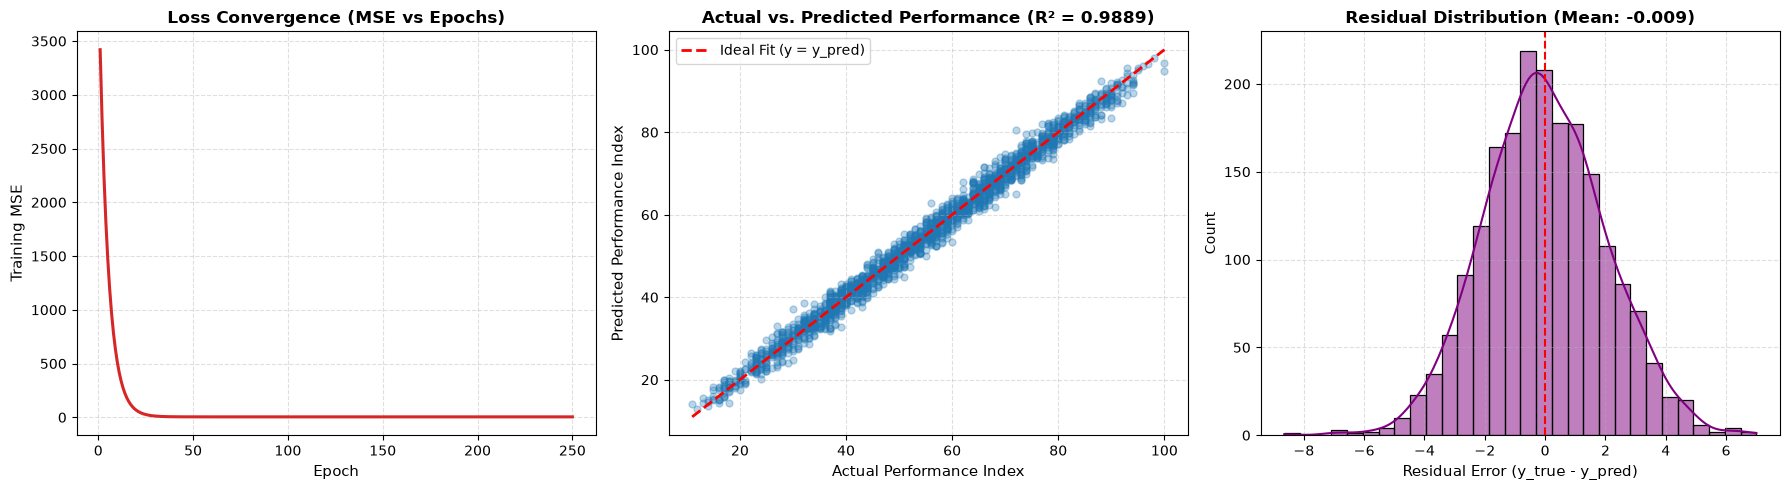

In [51]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Loss Convergence Curve
axes[0].plot(range(1, epochs + 1), loss_history, color='tab:red', lw=2.2)
axes[0].set_title('Loss Convergence (MSE vs Epochs)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=11)
axes[0].set_ylabel('Training MSE', fontsize=11)
axes[0].grid(True, linestyle='--', alpha=0.4)

# 2. Actual vs. Predicted (Ideal 45-degree line)
axes[1].scatter(y_test, y_test_pred, color='tab:blue', alpha=0.3, s=25)
line_pts = np.linspace(min(y_test.min(), y_test_pred.min()), max(y_test.max(), y_test_pred.max()), 100)
axes[1].plot(line_pts, line_pts, color='red', linestyle='--', lw=2, label='Ideal Fit (y = y_pred)')
axes[1].set_title(f'Actual vs. Predicted Performance (R² = {test_r2:.4f})', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Actual Performance Index', fontsize=11)
axes[1].set_ylabel('Predicted Performance Index', fontsize=11)
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.4)

# 3. Residual Distribution (Checking Normality & Homoscedasticity)
residuals = y_test - y_test_pred
sns.histplot(residuals.ravel(), kde=True, ax=axes[2], color='purple', bins=30)
axes[2].axvline(0, color='red', linestyle='--', lw=1.5)
axes[2].set_title(f'Residual Distribution (Mean: {np.mean(residuals):.3f})', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Residual Error (y_true - y_pred)', fontsize=11)
axes[2].grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

/tmp/ipykernel_364251/2203267965.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Standardized Coefficient', y='Feature', data=feature_importance, palette='viridis')


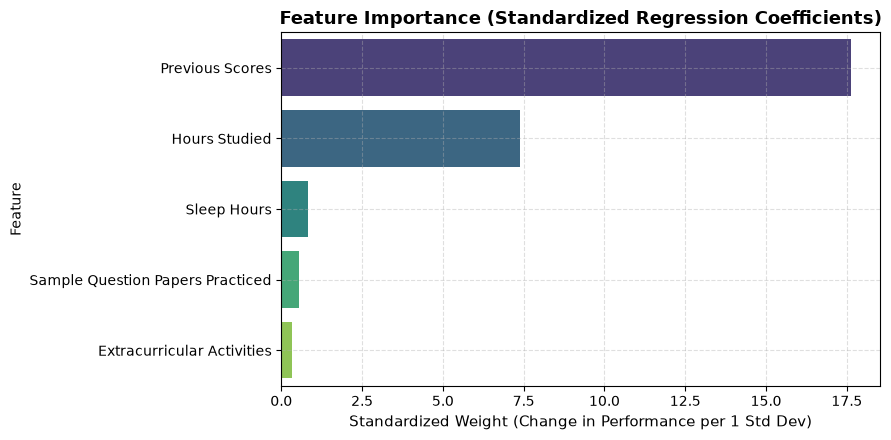

Feature Importance Ranking:
  Previous Scores                 : +17.6443
  Hours Studied                   : +7.3860
  Sleep Hours                     : +0.8190
  Sample Question Papers Practiced: +0.5527
  Extracurricular Activities      : +0.3313


In [52]:
# Standardized Feature Importance
feature_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Standardized Coefficient': w.ravel(),
    'Absolute Impact': np.abs(w.ravel())
}).sort_values('Absolute Impact', ascending=False)

plt.figure(figsize=(9, 4.5))
sns.barplot(x='Standardized Coefficient', y='Feature', data=feature_importance, palette='viridis')
plt.title('Feature Importance (Standardized Regression Coefficients)', fontsize=13, fontweight='bold')
plt.xlabel('Standardized Weight (Change in Performance per 1 Std Dev)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

print("Feature Importance Ranking:")
for _, row in feature_importance.iterrows():
    print(f"  {row['Feature']:<32}: {row['Standardized Coefficient']:+.4f}")

In [53]:
# Example: Predicting Performance Index for New Students
student_profiles = [
    {
        "Profile": "Average Student",
        "Hours Studied": 5,
        "Previous Scores": 70,
        "Extracurricular Activities": 1,
        "Sleep Hours": 7,
        "Sample Question Papers Practiced": 3
    },
    {
        "Profile": "High Achiever",
        "Hours Studied": 9,
        "Previous Scores": 95,
        "Extracurricular Activities": 1,
        "Sleep Hours": 8,
        "Sample Question Papers Practiced": 8
    },
    {
        "Profile": "Struggling Student",
        "Hours Studied": 2,
        "Previous Scores": 45,
        "Extracurricular Activities": 0,
        "Sleep Hours": 5,
        "Sample Question Papers Practiced": 1
    }
]

print(f"{'Student Profile':<24}{'Hours':<8}{'Prev Score':<12}{'Extra':<8}{'Sleep':<8}{'Papers':<8}{'Predicted Index':<16}")
print("=" * 85)

for p in student_profiles:
    raw_vec = np.array([[p['Hours Studied'], p['Previous Scores'], p['Extracurricular Activities'], p['Sleep Hours'], p['Sample Question Papers Practiced']]])
    scaled_vec = (raw_vec - mu) / sigma
    predicted_score = (np.dot(scaled_vec, w) + b).item()
    print(f"{p['Profile']:<24}{p['Hours Studied']:<8}{p['Previous Scores']:<12}{p['Extracurricular Activities']:<8}{p['Sleep Hours']:<8}{p['Sample Question Papers Practiced']:<8}{predicted_score:<16.2f}")

Student Profile         Hours   Prev Score  Extra   Sleep   Papers  Predicted Index 
Average Student         5       70          1       7       3       56.07           
High Achiever           9       95          1       8       8       94.37           
Struggling Student      2       45          0       5       1       20.04           
